# GIFT-Eval Metadata

Load the metadata that was collected and compare it to the values in Table 13 of the [GIFT-Eval paper](https://arxiv.org/pdf/2410.).

In [9]:
import pandas as pd
from pathlib import Path

path = Path("../../data/metadata/gift_eval.csv")
df = pd.read_csv(path)

print(f"Shape: {df.shape}")
df.head()

Shape: (97, 12)


,name,term,domain,freq,num_series,min_series_length,sum_series_length,target_dim,past_feat_dynamic_real_dim,prediction_length,validation_windows,test_windows
0,bitbrains_fast_storage/5T,short,Web/CloudOps,5T,1250,8640,21600000,2,5,48,162,18
1,bitbrains_fast_storage/5T,medium,Web/CloudOps,5T,1250,8640,21600000,2,5,480,16,2
2,bitbrains_fast_storage/5T,long,Web/CloudOps,5T,1250,8640,21600000,2,5,720,10,2
3,bitbrains_fast_storage/H,short,Web/CloudOps,H,1250,721,1802500,2,5,48,13,2
4,bitbrains_rnd/5T,short,Web/CloudOps,5T,500,8640,8640000,2,5,48,162,18


Count the number of observations in each domain

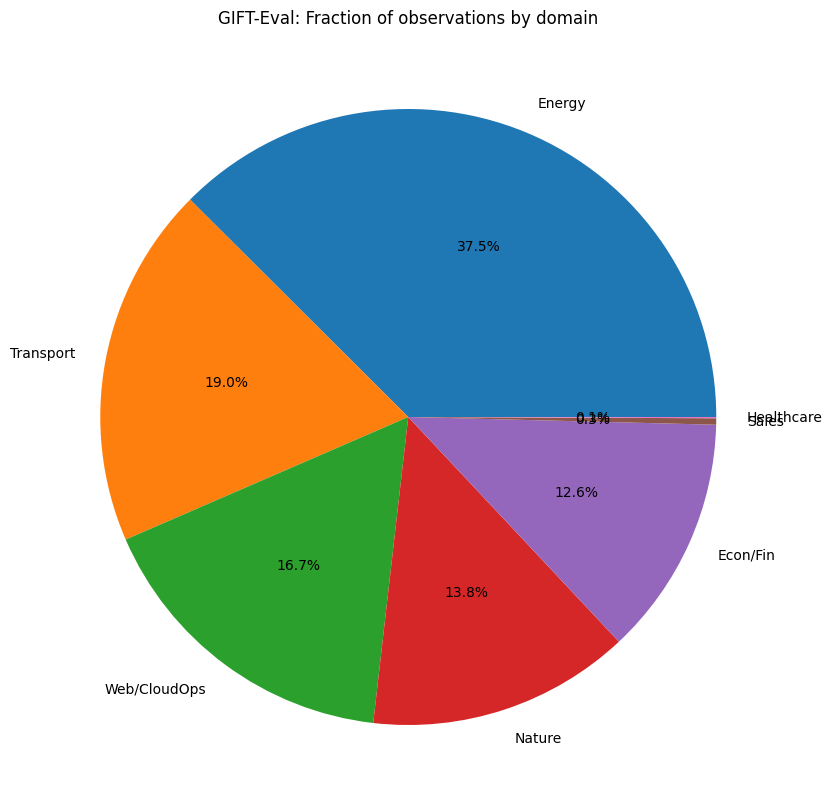

In [10]:
import matplotlib.pyplot as plt

df_unique = df.drop_duplicates(subset="name")
observations_by_domain = (
    df_unique.groupby("domain")["sum_series_length"].sum().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(
    observations_by_domain,
    labels=observations_by_domain.index,
    autopct="%1.1f%%",
)
ax.set_title("GIFT-Eval: Fraction of observations by domain")
plt.show()

Count the number of observations in each frequency

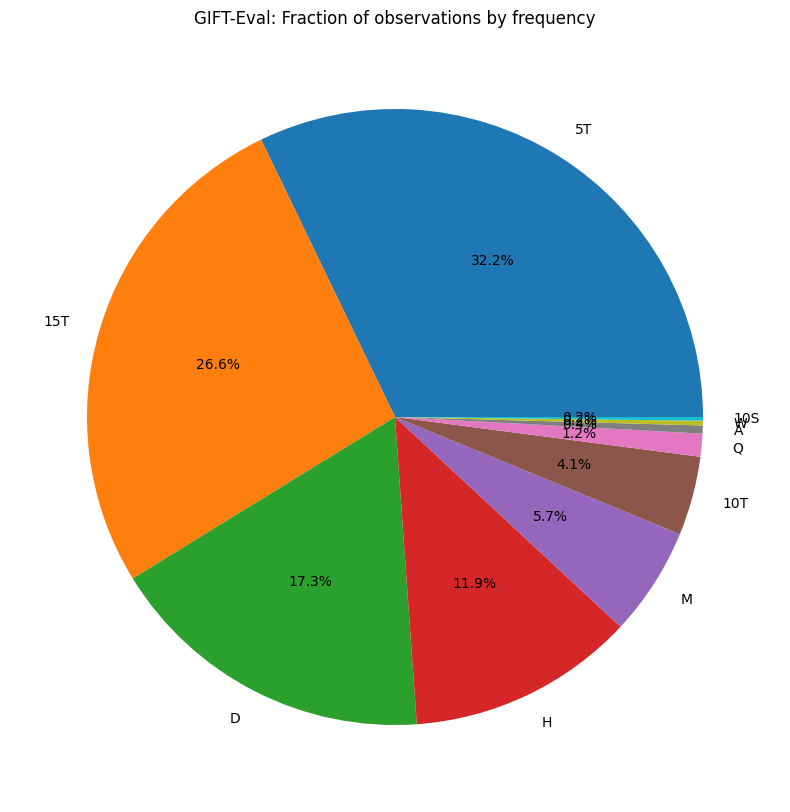

In [11]:
normalized_freq = df_unique["freq"].str.split("-").str[0]
observations_by_freq = (
    df_unique["sum_series_length"]
    .groupby(normalized_freq)
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(
    observations_by_freq,
    labels=observations_by_freq.index,
    autopct="%1.1f%%",
)
ax.set_title("GIFT-Eval: Fraction of observations by frequency")
plt.show()